# Notebook for computing linear trends and residuals

This notebook loads exported STCD data and analyses long-term behaviour.

- **Load data** produced by the companion notebook (e.g. `gop25wd03_stcd_licb_detr.csv`) from the `exports/` directory.
- **Specify input** by setting:
  - `PRODUCT` – type of product (`stcd`)
  - `SOLUTION` – solution identifier (e.g. `gop25wd04`)
  - `STATION` – station name (e.g. `licb`)
- **Parse** the raw table and convert MJD to calendar dates and decimal years.
- **Estimate a linear trend** for the East (`dE`), North (`dN`) and Up (`dU`) components (slope, intercept, R²).
- **Detrend the series** by subtracting the fitted line to obtain residuals.
- **Visualize** raw data, fitted trend and residuals.
- **Export residuals** to CSV (`exports/{solution}_{product}_{station}_detr.csv`) for later spectral or periodicity analysis.

### Imports

**Standard library**
- `calendar`, `re`, `sys`, `json`, `datetime`, `timedelta`, `pathlib.Path`, `typing.Iterable`

**Third-party**
- `numpy` – numerical arrays (https://numpy.org)
- `pandas` – data frames (https://pandas.pydata.org)
- `matplotlib.pyplot` – plotting (https://matplotlib.org)
- `scipy.stats` – statistics & regression (https://scipy.org)

In [1]:
# --- Standard library ---
import calendar                           # calendar utilities
import re                                 # regular expressions
import sys                                # system-specific parameters and functions
import json                               # JSON serialization
from pathlib import Path                  # filesystem paths
from datetime import datetime, timedelta  # date/time handling
from typing import Iterable               # typing: generic iterable

# --- Third-party packages ---
try:
    import numpy as np                    # numerical arrays and vectorized math
except ImportError as e:
    raise RuntimeError("Missing dependency: 'numpy'. Install it with:\n  pip install numpy") from e

try:
    import pandas as pd                   # tabular dataframes
except ImportError as e:
    raise RuntimeError("Missing dependency: 'pandas'. Install it with:\n  pip install pandas") from e

try:
    import matplotlib.pyplot as plt       # plotting
    import matplotlib.ticker as mticker   # axis tick formatting
except ImportError as e:
    raise RuntimeError("Missing dependency: 'matplotlib'. Install it with:\n  pip install matplotlib") from e

try:
    from scipy import stats               # statistical tools
except ImportError as e:
    raise RuntimeError("Missing dependency: 'scipy'. Install it with:\n  pip install scipy") from e

# # --- doris package ---
# _src = Path("../../src").resolve()
# if str(_src) not in sys.path:
#     sys.path.insert(0, str(_src))

try:
    from doris.output.plots import (
        uniform_y_scale_policy,
        set_unit_ticks,
    )
    from doris.analysis.stations.trend import (
        fit_piecewise_trend,
        fit_linear_trend,
    )

except ImportError as e:
    raise RuntimeError(
        "Missing doris modules. Make sure the project src path is on PYTHONPATH "
        "or run the notebook from the expected directory: notebooks/stations."
    ) from e

### Paths and constants

In [2]:
# --- Dataset selection ---
PRODUCT  = "stcd".strip().lower()
SOLUTION = "gop25wd04".strip().lower()
STATION  = "LICB".strip().lower()

# --- Output root ---
OUTPUT_ROOT = Path("../../data")

# --- Directory layout ---
DATA_DIR   = OUTPUT_ROOT / PRODUCT / SOLUTION
EXPORT_DIR = DATA_DIR / "exports" / STATION
IMAGES_DIR = DATA_DIR / "images" / STATION

# Create dirs
for d in [DATA_DIR, EXPORT_DIR, IMAGES_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# --- File names ---
BASE_NAME = f"{SOLUTION}_{PRODUCT}_{STATION}"

DETR_CSV   = EXPORT_DIR / f"{BASE_NAME}_detr.csv"
IMAGE_NAME = BASE_NAME

# --- Plot title ---
title = f"{SOLUTION} – {PRODUCT} – {STATION}"

# --- Components ---
components = ["dE", "dN", "dU"]

# --- Debug ---
print("📁 DATA_DIR:   ", DATA_DIR)
print("📤 EXPORT_DIR: ", EXPORT_DIR)
print("🖼 IMAGES_DIR: ", IMAGES_DIR)

📁 DATA_DIR:    ..\..\data\stcd\gop25wd04
📤 EXPORT_DIR:  ..\..\data\stcd\gop25wd04\exports\licb
🖼 IMAGES_DIR:  ..\..\data\stcd\gop25wd04\images\licb


### load STCD data
Finds the first numeric row in a plaintext STCD table and reads the rest as whitespace-delimited data.

In [3]:
def load_stcd(filepath):
    # Find the first line of the numeric table
    with open(filepath, 'r') as f:
        for i, line in enumerate(f):
            # data lines start with some whitespace then a digit
            if line.startswith('  ') and line.lstrip()[0].isdigit():
                skiprows = i
                break

    # Read the rest using any run of whitespace as delimiter
    df = pd.read_csv(
        filepath,
        sep=r'\s+',
        header=None,
        skiprows=skiprows,
        names=["MJD", "dX", "dY", "dZ", "sX", "sY", "sZ", "dE", "dN", "dU", "sE", "sN", "sU"]
    )
    return df

# Path to data 
folder_path = f"{DATA_DIR}/{SOLUTION}.{PRODUCT}.{STATION}"

# Example usage:
df = load_stcd(folder_path)

# Display the DataFrame
df

,MJD,dX,dY,dZ,sX,sY,sZ,dE,dN,dU,sE,sN,sU
0,53704.5,-30.9,112.9,99.4,19.8,33.1,14.5,116.5,100.2,-10.8,32.8,14.5,20.3
1,53711.5,-58.4,117.2,107.2,11.0,16.9,7.4,125.4,108.2,-37.2,16.7,7.4,11.2
2,53718.5,-28.5,106.8,100.0,8.6,16.6,6.3,110.1,100.8,-9.5,16.4,6.3,8.9
3,53725.5,-37.2,123.8,106.8,5.9,9.8,4.1,128.3,107.6,-15.2,9.7,4.1,6.1
4,53732.5,-45.4,112.3,110.3,5.6,10.1,3.9,118.3,111.2,-25.2,10.0,3.9,5.8
...,...,...,...,...,...,...,...,...,...,...,...,...,...
987,60823.5,-130.4,555.1,464.4,3.9,6.5,2.9,569.1,467.7,-32.4,6.5,2.9,4.0
988,60830.5,-138.8,566.3,473.2,3.8,6.1,2.7,581.5,476.6,-38.7,6.0,2.7,3.9
989,60837.5,-157.5,611.5,460.3,4.7,7.9,3.4,629.3,463.7,-49.7,7.8,3.4,4.8
990,60844.5,-116.7,548.8,479.8,4.3,7.2,3.2,560.6,483.2,-19.9,7.2,3.2,4.4


### Dominant MJD step  
Determines the most common time interval (in days) between MJD values.

In [4]:
# Function to find the dominant sampling step from MJD
def infer_mjd_step(df: pd.DataFrame) -> int:
    """Return the most frequent MJD step (days) from consecutive differences in df['MJD']."""
    s = pd.to_numeric(df["MJD"], errors="coerce").dropna().to_numpy()
    if s.size < 2:
        raise ValueError("Not enough MJD values to infer step.")
    s = np.sort(s)

    diffs = np.diff(s)
    diffs = diffs[diffs > 0]
    if diffs.size == 0:
        raise ValueError("No positive MJD differences found.")

    steps = np.rint(diffs).astype(int)

    vals, counts = np.unique(steps, return_counts=True)
    maxc = counts.max()
    return int(min(vals[counts == maxc]))  #choose the smallest

# Usage
step = infer_mjd_step(df)
print(f"MJD step: {step} day(s)")

MJD step: 7 day(s)


### Regularize MJD (fill gaps)
Creates a regular MJD grid (using inferred `step`), inserts missing epochs as new rows with NaN, and returns `(df_filled, step, rows_added)`.

In [5]:
# Regularize MJD to a fixed step: insert missing epochs as NaN rows
def fill_missing_mjd(df: pd.DataFrame, step: int):
    if step is None or step <= 0:
        raise ValueError("`step` must be a positive integer (days).")
    step = int(step)

    # sorted unique MJD epochs
    s = np.unique(np.sort(pd.to_numeric(df["MJD"], errors="coerce").dropna().to_numpy()))
    if s.size == 0:
        raise ValueError("No MJD values found.")

    # build full grid from first to last epoch with given step
    start, end = s[0], s[-1]
    n = int(round((end - start) / step)) + 1
    grid = start + step * np.arange(n, dtype=float)

    # reindex: missing epochs become NaN rows
    out = df.copy().set_index("MJD").reindex(grid)
    out.index.name = "MJD"
    out = out.reset_index().rename(columns={"index": "MJD"})

    rows_added = int(len(grid) - len(s))
    print(f"Regularized MJD grid with step={step} day(s) | rows added: {rows_added}")
    return out, rows_added

# Usage (step already computed elsewhere):
step = infer_mjd_step(df)
df_filled, rows_added = fill_missing_mjd(df, step)
df_filled = df

Regularized MJD grid with step=7 day(s) | rows added: 30


### MJD → datetime & filtering

**What it does**
- Converts `MJD` to calendar `Date` using epoch **1858-11-17** (`Date = 1858-11-17 + MJD days`).
- Stores the result in a new column `Date`.
- KeepsOnly: `Date, dE, dN, dU, sE, sN, sU` → saved as `df_filt`.

In [6]:
# Function to convert MJD (Modified Julian Date) to a standard datetime
def mjd_to_date(mjd):
    return datetime(1858, 11, 17) + timedelta(days=mjd)

# Apply the conversion function to the 'MJD' column and save results in 'Date'
df_filled["Date"] = df_filled["MJD"].apply(mjd_to_date)

# Filtering: Date, East/North/Up offsets and their uncertainties
df_filt = df_filled[["Date", "dE", "dN", "dU", "sE", "sN", "sU"]].copy()

# Display the filtered DataFrame
df_filt

,Date,dE,dN,dU,sE,sN,sU
0,2005-11-30 12:00:00,116.5,100.2,-10.8,32.8,14.5,20.3
1,2005-12-07 12:00:00,125.4,108.2,-37.2,16.7,7.4,11.2
2,2005-12-14 12:00:00,110.1,100.8,-9.5,16.4,6.3,8.9
3,2005-12-21 12:00:00,128.3,107.6,-15.2,9.7,4.1,6.1
4,2005-12-28 12:00:00,118.3,111.2,-25.2,10.0,3.9,5.8
...,...,...,...,...,...,...,...
987,2025-05-28 12:00:00,569.1,467.7,-32.4,6.5,2.9,4.0
988,2025-06-04 12:00:00,581.5,476.6,-38.7,6.0,2.7,3.9
989,2025-06-11 12:00:00,629.3,463.7,-49.7,7.8,3.4,4.8
990,2025-06-18 12:00:00,560.6,483.2,-19.9,7.2,3.2,4.4


### Decimal year (precise)

**What it does**
- Adds `year` as a decimal timestamp from `Date` using a **seconds-based ratio**:
  `year + elapsed_seconds / year_length_seconds`.

**How computed**
- `elapsed_seconds = (dt - Jan 1 of year).total_seconds()`
- `year_length_seconds = (Jan 1 of next year - Jan 1 of year).total_seconds()`

In [7]:
# Add a new column “year” to df_filt, representing the date as a decimal year
def decimal_year(dt):
    y = dt.year
    start = datetime(y, 1, 1)
    end   = datetime(y + 1, 1, 1)
    return y + (dt - start).total_seconds() / (end - start).total_seconds()

df_filt['year'] = df_filt['Date'].apply(decimal_year)
df_filt

,Date,dE,dN,dU,sE,sN,sU,year
0,2005-11-30 12:00:00,116.5,100.2,-10.8,32.8,14.5,20.3,2005.913699
1,2005-12-07 12:00:00,125.4,108.2,-37.2,16.7,7.4,11.2,2005.932877
2,2005-12-14 12:00:00,110.1,100.8,-9.5,16.4,6.3,8.9,2005.952055
3,2005-12-21 12:00:00,128.3,107.6,-15.2,9.7,4.1,6.1,2005.971233
4,2005-12-28 12:00:00,118.3,111.2,-25.2,10.0,3.9,5.8,2005.990411
...,...,...,...,...,...,...,...,...
987,2025-05-28 12:00:00,569.1,467.7,-32.4,6.5,2.9,4.0,2025.404110
988,2025-06-04 12:00:00,581.5,476.6,-38.7,6.0,2.7,3.9,2025.423288
989,2025-06-11 12:00:00,629.3,463.7,-49.7,7.8,3.4,4.8,2025.442466
990,2025-06-18 12:00:00,560.6,483.2,-19.9,7.2,3.2,4.4,2025.461644


### Display data

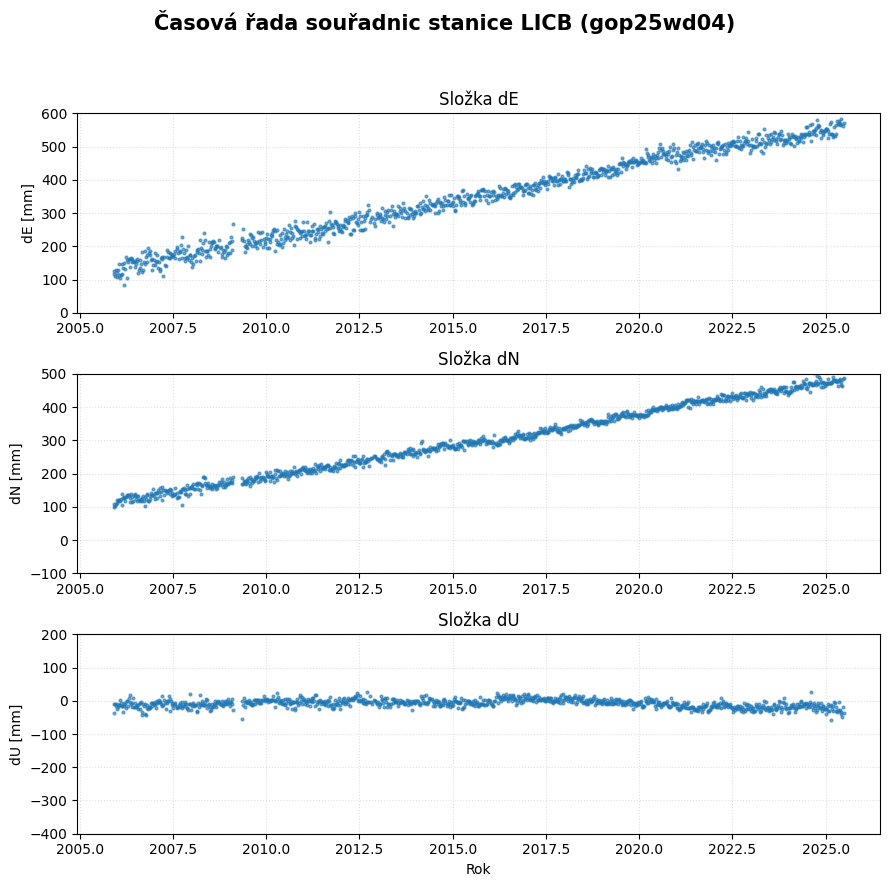

Saved PDF → ..\..\data\stcd\gop25wd04\images\licb


In [8]:
# --- Plot: station coordinate time series ---

components = components  # e.g., ["dE", "dN", "dU"]

fig, axes = plt.subplots(len(components), 1, figsize=(9, 9), sharex=True, sharey=False)

# Ensure axes is always iterable
if len(components) == 1:
    axes = [axes]

x_vals = df_filt["year"].values  # decimal year as x-axis

component_titles = {
    "dE": "Složka dE",
    "dN": "Složka dN",
    "dU": "Složka dU",
}

for ax, comp in zip(axes, components):
    y_vals = df_filt[comp].values  # component values in mm

    # Plot raw observations
    ax.plot(
        x_vals, y_vals,
        ".",
        ms=4,
        alpha=0.6,
        label=f"{comp} data"
    )

    # Subplot styling
    ax.set_title(component_titles.get(comp, comp), fontweight="normal")
    ax.set_ylabel(f"{comp} [mm]")
    ax.tick_params(axis="x", labelbottom=True)
    ax.grid(True, linestyle=":", alpha=0.4)

# X label only on the bottom subplot
axes[-1].set_xlabel("Rok")

# Main figure title
fig.suptitle(f"Časová řada souřadnic stanice {STATION.upper()} ({SOLUTION})", fontsize=15, fontweight="bold")

# Apply consistent Y-axis scaling across subplots
tick_step, common_window = uniform_y_scale_policy(
    axes=axes,
    df=df_filt,
    components=components,
    tick_step=None,
    target_ticks=6,
    tightness="tight",
    min_ticks=3,
    robust=True,
    q_low=1.0,
    q_high=99.0
)

# Adjust layout to avoid overlap with suptitle
plt.tight_layout(rect=[0, 0, 1, 0.95])

# Save figure
image_file_name = f"{IMAGE_NAME}_raw_data"
fig.savefig(IMAGES_DIR / f"{image_file_name}.pdf", bbox_inches="tight")

plt.show()

print(f"Saved PDF → {IMAGES_DIR}")

### Time window selection
Filters data to a `[START, END]` timestamp window (or full range if `None`), and then replaces `df_filt` with the selected subset.

In [9]:
# --- window (None = open interval; accepts 'YYYY-MM-DD HH:MM') ---
START = "2015-01-01 00:00"
END   = "2025-12-31 23:59"

# 1) Slice by full timestamp (date+time)
df_all = df_filt.copy()
df_all["Date"] = pd.to_datetime(df_all["Date"], errors="coerce")

# Fall back to full range if START/END is None
start_ts = pd.to_datetime(START) if START else df_all["Date"].min()
end_ts   = pd.to_datetime(END)   if END   else df_all["Date"].max()

# Closed interval [start_ts, end_ts]
mask = df_all["Date"].between(start_ts, end_ts, inclusive="both")
df_win = (df_all.loc[mask]
                .sort_values("Date")
                .reset_index(drop=True))

print(
    f"Window rows: {len(df_win)} | range: "
    f"{(df_win['Date'].min() if len(df_win) else '—')} → "
    f"{(df_win['Date'].max() if len(df_win) else '—')}"
)

# 3) From now on, work with the window only
df_filt = df_win

Window rows: 543 | range: 2015-01-07 12:00:00 → 2025-06-25 12:00:00


### Plot selected subset
plots all data vs. the selected window,

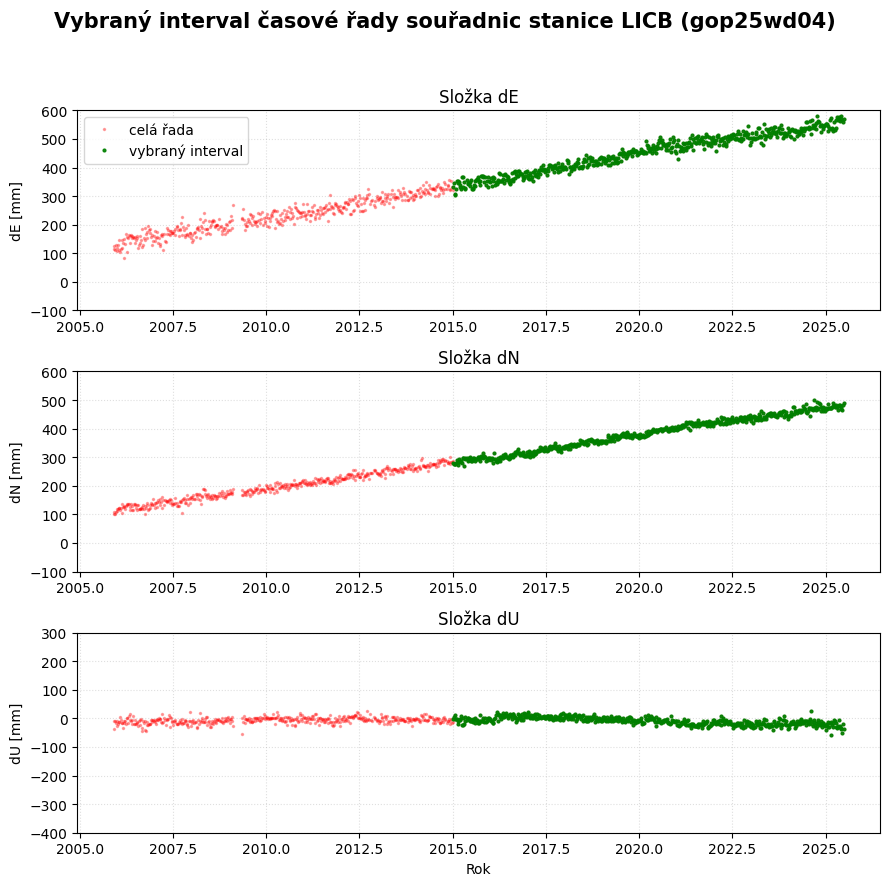

Saved PDF → ..\..\data\stcd\gop25wd04\images\licb


In [10]:
# --- Plot: station coordinate time series with selected window ---

components = components  # e.g., ["dE", "dN", "dU"]

fig, axes = plt.subplots(len(components), 1, figsize=(9, 9), sharex=True, sharey=False)

# Ensure axes is always iterable
if len(components) == 1:
    axes = [axes]

x_all = df_all["year"].values
x_win = df_win["year"].values

component_titles = {
    "dE": "Složka dE",
    "dN": "Složka dN",
    "dU": "Složka dU",
}

for ax, comp in zip(axes, components):
    y_all = pd.to_numeric(df_all[comp], errors="coerce").to_numpy()
    y_win = pd.to_numeric(df_win[comp], errors="coerce").to_numpy()

    # Plot all observations as background
    ax.plot(
        x_all, y_all,
        ".",
        ms=3,
        alpha=0.30,
        color="red",
        label="celá řada"
    )

    # Plot selected window as highlighted observations
    ax.plot(
        x_win, y_win,
        ".",
        ms=4,
        alpha=0.90,
        color="green",
        label="vybraný interval"
    )

    # Subplot styling
    ax.set_title(component_titles.get(comp, comp), fontweight="normal")
    ax.set_ylabel(f"{comp} [mm]")
    ax.tick_params(axis="x", labelbottom=True)
    ax.grid(True, linestyle=":", alpha=0.4)

# X label only on the bottom subplot
axes[-1].set_xlabel("Rok")

# Main figure title
fig.suptitle(
    f"Vybraný interval časové řady souřadnic stanice {STATION.upper()} ({SOLUTION})",
    fontsize=15,
    fontweight="bold"
)

# Add one shared legend
axes[0].legend(loc="best")

# Apply consistent Y-axis scaling across subplots
tick_step, common_window = uniform_y_scale_policy(
    axes=axes,
    df=df_all,
    components=components,
    tick_step=None,
    target_ticks=6,
    tightness="loose",
    min_ticks=3,
    robust=True,
    q_low=1.0,
    q_high=99.0
)

# Adjust layout to avoid overlap with suptitle
plt.tight_layout(rect=[0, 0, 1, 0.95])

# Save figure
image_file_name = f"{IMAGE_NAME}_cut"
fig.savefig(IMAGES_DIR / f"{image_file_name}.pdf", bbox_inches="tight")

plt.show()

print(f"Saved PDF → {IMAGES_DIR}")

In [11]:
# --- Export selected window before detrending ---

# Keep the same working dataframe that later trend blocks use
df_filt = df_win.copy()

# Build output path
RAW_WINDOW_CSV = EXPORT_DIR / f"{IMAGE_NAME}_selected_data.csv"

# Export non-detrended selected window
df_filt.to_csv(RAW_WINDOW_CSV, index=False, float_format="%.6f")

print(f"Saved raw window CSV -> {RAW_WINDOW_CSV.resolve()}")
print(f"Rows: {len(df_filt)}")
display(df_filt.head())

Saved raw window CSV -> C:\Users\michal\Desktop\MasterThesis-DorisAnalysis\data\stcd\gop25wd04\exports\licb\gop25wd04_stcd_licb_selected_data.csv
Rows: 543


,Date,dE,dN,dU,sE,sN,sU,year
0,2015-01-07 12:00:00,333.1,279.0,-3.4,8.2,3.4,4.8,2015.017808
1,2015-01-14 12:00:00,346.4,276.7,5.1,7.8,3.4,4.9,2015.036986
2,2015-01-21 12:00:00,305.3,275.2,-1.7,8.6,3.6,5.2,2015.056164
3,2015-01-28 12:00:00,308.6,275.0,10.3,8.4,3.5,5.0,2015.075342
4,2015-02-04 12:00:00,325.1,278.2,-1.4,8.2,3.4,5.1,2015.094521


## Shared Trend Helpers

In [12]:
# --- Shared settings and helpers for trend analysis ---

WEIGHTED = True

sigma_map = {
    "dE": "sE",
    "dN": "sN",
    "dU": "sU",
}

TREND_EXPORTS = {
    "weighted_1seg": {
        "label": "Weighted 1-segment linear trend",
        "csv": EXPORT_DIR / f"{IMAGE_NAME}_detr_weighted_1seg.csv",
        "fit_plot": IMAGES_DIR / f"{IMAGE_NAME}_trend_weighted_1seg.pdf",
        "residual_plot": IMAGES_DIR / f"{IMAGE_NAME}_residuals_weighted_1seg.pdf",
        "tex": EXPORT_DIR / f"{IMAGE_NAME}_trend_table_weighted_1seg.tex",
    },
    "weighted_2seg": {
        "label": "Weighted 2-segment linear trend",
        "csv": EXPORT_DIR / f"{IMAGE_NAME}_detr_weighted_2seg.csv",
        "fit_plot": IMAGES_DIR / f"{IMAGE_NAME}_trend_weighted_2seg.pdf",
        "residual_plot": IMAGES_DIR / f"{IMAGE_NAME}_residuals_weighted_2seg.pdf",
        "tex": EXPORT_DIR / f"{IMAGE_NAME}_trend_table_weighted_2seg.tex",
    },
    "weighted_multiseg": {
        "label": "Weighted multi-segment linear trend",
        "csv": EXPORT_DIR / f"{IMAGE_NAME}_detr_weighted_multiseg.csv",
        "fit_plot": IMAGES_DIR / f"{IMAGE_NAME}_trend_weighted_multiseg.pdf",
        "residual_plot": IMAGES_DIR / f"{IMAGE_NAME}_residuals_weighted_multiseg.pdf",
        "tex": EXPORT_DIR / f"{IMAGE_NAME}_trend_table_weighted_multiseg.tex",
    },
}


def component_sigma(comp):
    if not WEIGHTED:
        return None

    return pd.to_numeric(
        df_filt[sigma_map[comp]],
        errors="coerce"
    ).to_numpy()


def trend_summary_rows(results, variant):
    rows = []

    for comp in components:
        trend = results.get(comp)

        if trend is None:
            rows.append({
                "variant": variant,
                "axis": comp,
                "n_segments": 0,
                "breakpoints": "",
                "slopes": "",
                "intercepts": "",
                "r2": np.nan,
                "rss": np.nan,
                "wrss": np.nan,
                "bic": np.inf,
                "weighted": WEIGHTED,
                "bic_metric": "wrss" if WEIGHTED else "rss",
            })
            continue

        rows.append({
            "variant": variant,
            "axis": comp,
            "n_segments": trend.n_segments,
            "breakpoints": ", ".join(f"{bp:.3f}" for bp in trend.breakpoints),
            "slopes": ", ".join(f"{seg.slope:.3f}" for seg in trend.segments),
            "intercepts": ", ".join(f"{seg.intercept:.3f}" for seg in trend.segments),
            "r2": trend.r2,
            "rss": trend.rss,
            "wrss": trend.wrss,
            "bic": trend.bic,
            "weighted": trend.weighted,
            "bic_metric": trend.bic_metric,
        })

    return rows


def build_detrended_dataframe(results):
    out = df_filt.copy()

    for comp in components:
        trend = results.get(comp)

        if trend is None:
            out[f"fit_{comp}"] = np.nan
            out[f"res_{comp}"] = np.nan
            out[f"seg_{comp}"] = -1
            continue

        trend_df = trend.to_dataframe()

        out[f"fit_{comp}"] = trend_df["fitted"].to_numpy()
        out[f"res_{comp}"] = trend_df["residual"].to_numpy()
        out[f"seg_{comp}"] = trend_df["segment_id"].to_numpy()

    return out

## Weighted 1-Segment Trend

This block fits the weighted one-segment trend and exports its raw PDF, fitted-trend PDF, detrended CSV, residual PDF, and LaTeX table.

In [13]:
# --- Weighted 1-segment linear trend ---

VARIANT = "weighted_1seg"
CONFIG = TREND_EXPORTS[VARIANT]

x_all = pd.to_numeric(df_filt["year"], errors="coerce").to_numpy()

trend1_results = {}

for comp in components:
    y_all = pd.to_numeric(df_filt[comp], errors="coerce").to_numpy()

    try:
        trend1_results[comp] = fit_linear_trend(
            x_all,
            y_all,
            sigma=component_sigma(comp),  # weighted fit
            bic_metric="auto",
        )
    except ValueError:
        trend1_results[comp] = None

rows = []

for comp in components:
    trend = trend1_results.get(comp)

    if trend is None:
        rows.append({
            "axis": comp,
            "slope": np.nan,
            "intercept": np.nan,
            "r2": np.nan,
            "rss": np.nan,
            "wrss": np.nan,
            "bic": np.inf,
            "weighted": True,
        })
        continue

    rows.append({
        "axis": comp,
        "slope": trend.slope,
        "intercept": trend.intercept,
        "r2": trend.r2,
        "rss": trend.rss,
        "wrss": trend.wrss,
        "bic": trend.bic,
        "weighted": trend.weighted,
    })

trend1_df = pd.DataFrame(rows).set_index("axis", drop=False)

display(trend1_df[["slope", "intercept", "r2", "rss", "wrss", "bic", "weighted"]].round(3))

,slope,intercept,r2,rss,wrss,bic,weighted
axis,,,,,,,
dE,21.882,-43754.011,0.953,117782.943,2377.842,814.518,True
dN,19.875,-39768.550,0.982,35245.361,3851.866,1076.442,True
dU,-3.038,6129.903,0.427,53457.715,2781.574,899.673,True


In [14]:
# --- Weighted 1-segment LaTeX table ---

latex_1seg = trend1_df[
    ["axis", "slope", "intercept", "r2", "wrss", "bic", "weighted"]
].round(3).to_latex(
    index=False,
    caption="Vážený lineární trend bez zlomů",
    label=f"tab:{IMAGE_NAME}_weighted_1seg",
    escape=False,
)

CONFIG["tex"].write_text(latex_1seg, encoding="utf-8")

print(latex_1seg)
print("Saved TeX ->", CONFIG["tex"].resolve())

\begin{table}
\caption{Vážený lineární trend bez zlomů}
\label{tab:gop25wd04_stcd_licb_weighted_1seg}
\begin{tabular}{lrrrrrr}
\toprule
axis & slope & intercept & r2 & wrss & bic & weighted \\
\midrule
dE & 21.882000 & -43754.011000 & 0.953000 & 2377.842000 & 814.518000 & True \\
dN & 19.875000 & -39768.550000 & 0.982000 & 3851.866000 & 1076.442000 & True \\
dU & -3.038000 & 6129.903000 & 0.427000 & 2781.574000 & 899.673000 & True \\
\bottomrule
\end{tabular}
\end{table}

Saved TeX -> C:\Users\michal\Desktop\MasterThesis-DorisAnalysis\data\stcd\gop25wd04\exports\licb\gop25wd04_stcd_licb_trend_table_weighted_1seg.tex


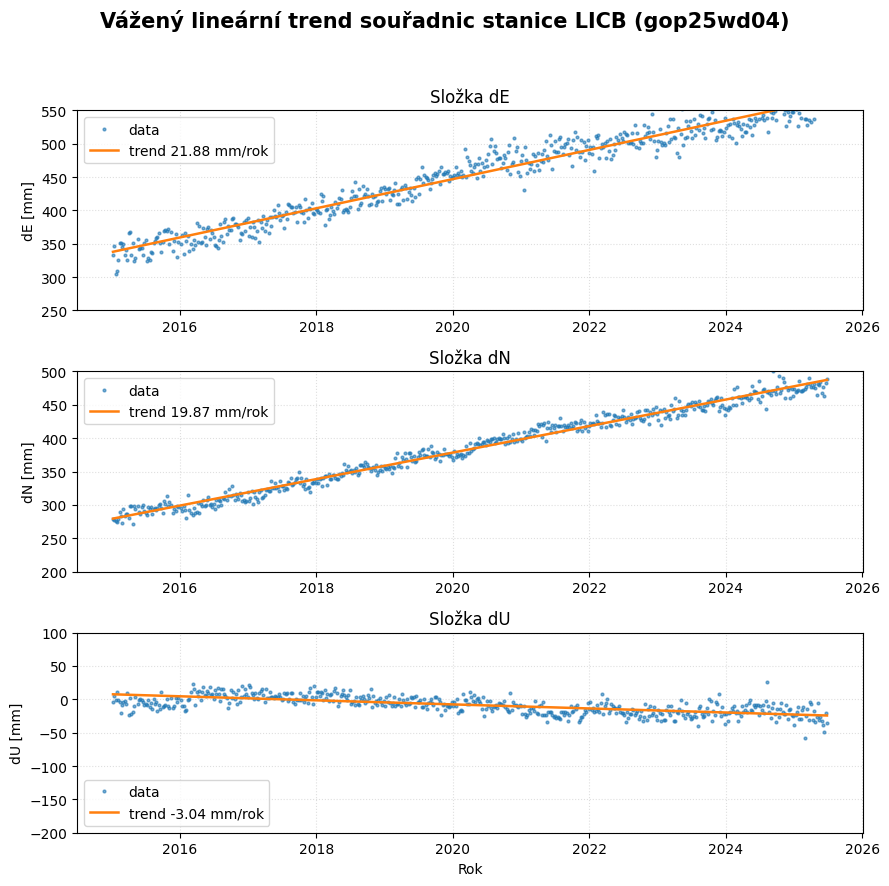

Saved PDF -> C:\Users\michal\Desktop\MasterThesis-DorisAnalysis\data\stcd\gop25wd04\images\licb\gop25wd04_stcd_licb_trend_weighted_1seg.pdf


In [15]:
# --- Plot: weighted 1-segment linear trend ---

components = components

fig, axes = plt.subplots(len(components), 1, figsize=(9, 9), sharex=True, sharey=False)

if len(components) == 1:
    axes = [axes]

x_vals = df_filt["year"].values

component_titles = {
    "dE": "Složka dE",
    "dN": "Složka dN",
    "dU": "Složka dU",
}

for ax, comp in zip(axes, components):
    y_vals = pd.to_numeric(df_filt[comp], errors="coerce").to_numpy()

    # Data
    ax.plot(
        x_vals, y_vals,
        ".",
        ms=4,
        alpha=0.6,
        color="tab:blue",
        label="data"
    )

    # Trend
    trend = trend1_results.get(comp)

    if trend is not None:
        x_fit = np.linspace(np.nanmin(x_vals), np.nanmax(x_vals), 200)
        y_fit = trend.intercept + trend.slope * x_fit

        ax.plot(
            x_fit, y_fit,
            "-",
            lw=1.8,
            color="tab:orange",   # 🔥 matplotlib default orange
            label=f"trend {trend.slope:.2f} mm/rok"
        )

    # Styling
    ax.set_title(component_titles.get(comp, comp), fontweight="normal")
    ax.set_ylabel(f"{comp} [mm]")
    ax.tick_params(axis="x", labelbottom=True)
    ax.grid(True, linestyle=":", alpha=0.4)

    # 🔥 legenda pro každý subplot
    ax.legend(loc="best")

axes[-1].set_xlabel("Rok")

fig.suptitle(
    f"Vážený lineární trend souřadnic stanice {STATION.upper()} ({SOLUTION})",
    fontsize=15,
    fontweight="bold"
)

uniform_y_scale_policy(
    axes=axes,
    df=df_filt,
    components=components,
    tick_step=None,
    target_ticks=6,
    tightness="tight",
    min_ticks=3,
    robust=True,
    q_low=1.0,
    q_high=99.0
)

plt.tight_layout(rect=[0, 0, 1, 0.95])

fig.savefig(CONFIG["fit_plot"], bbox_inches="tight")

plt.show()

print("Saved PDF ->", CONFIG["fit_plot"].resolve())

In [16]:
# Weighted 1-segment detrending and CSV export
df_detr_1seg = build_detrended_dataframe(trend1_results)
df_detr_1seg.to_csv(CONFIG["csv"], index=False, float_format="%.6f")
print("Saved CSV ->", CONFIG["csv"].resolve())
display(df_detr_1seg[["year"] + [f"res_{c}" for c in components]].head())

Saved CSV -> C:\Users\michal\Desktop\MasterThesis-DorisAnalysis\data\stcd\gop25wd04\exports\licb\gop25wd04_stcd_licb_detr_weighted_1seg.csv


,year,res_dE,res_dN,res_dU
0,2015.017808,-4.826698,-0.438070,-10.933420
1,2015.036986,8.053654,-3.119230,-2.375150
2,2015.056164,-33.465994,-5.000389,-9.116880
3,2015.075342,-30.585642,-5.581549,2.941390
4,2015.094521,-14.505291,-2.762709,-8.700339


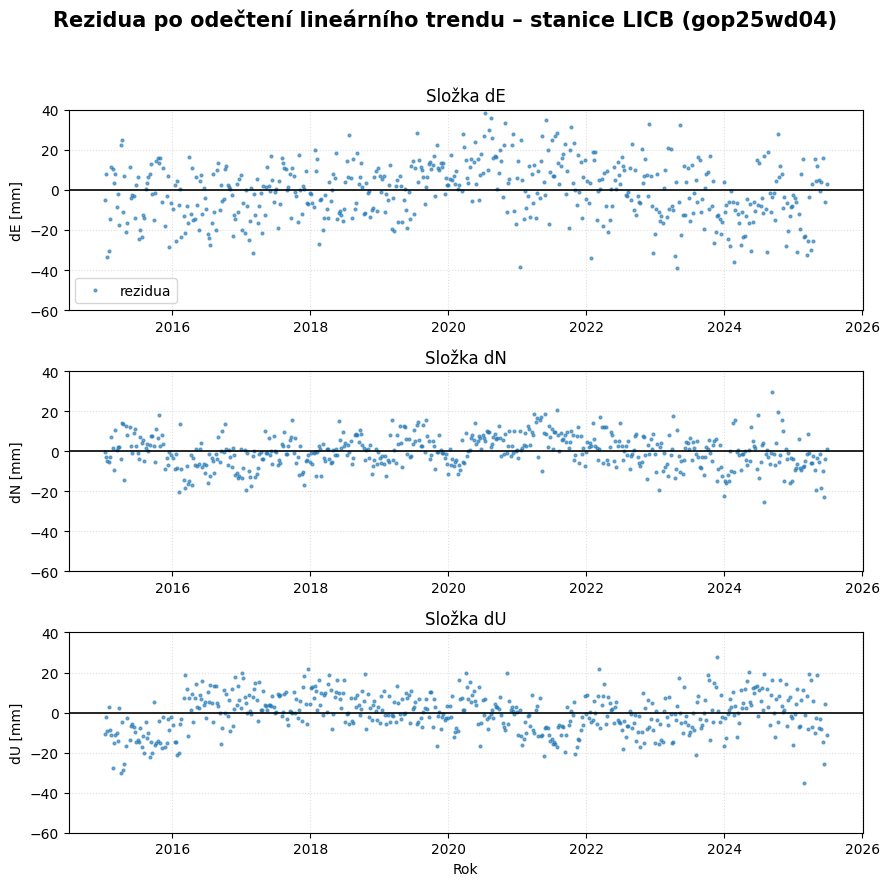

Saved PDF -> C:\Users\michal\Desktop\MasterThesis-DorisAnalysis\data\stcd\gop25wd04\images\licb\gop25wd04_stcd_licb_residuals_weighted_1seg.pdf


In [17]:
# --- Plot: residuals (weighted 1-segment) ---

components = components

fig, axes = plt.subplots(len(components), 1, figsize=(9, 9), sharex=True, sharey=False)

if len(components) == 1:
    axes = [axes]

x_vals = df_detr_1seg["year"].values

component_titles = {
    "dE": "Složka dE",
    "dN": "Složka dN",
    "dU": "Složka dU",
}

for i, (ax, comp) in enumerate(zip(axes, components)):
    y_res = pd.to_numeric(df_detr_1seg[f"res_{comp}"], errors="coerce").to_numpy()

    # Residuals
    ax.plot(
        x_vals, y_res,
        ".",
        ms=4,
        alpha=0.6,
        color="tab:blue",
        label="rezidua" if i == 0 else None  # legend only once
    )

    # Zero reference line
    ax.axhline(
        0,
        color="black",
        lw=1.2,
        linestyle="-"
    )

    # Styling
    ax.set_title(component_titles.get(comp, comp), fontweight="normal")
    ax.set_ylabel(f"{comp} [mm]")
    ax.tick_params(axis="x", labelbottom=True)
    ax.grid(True, linestyle=":", alpha=0.4)

    # Legend only on first subplot
    if i == 0:
        ax.legend(loc="best")

axes[-1].set_xlabel("Rok")

fig.suptitle(
    f"Rezidua po odečtení lineárního trendu – stanice {STATION.upper()} ({SOLUTION})",
    fontsize=15,
    fontweight="bold"
)

uniform_y_scale_policy(
    axes=axes,
    df=df_detr_1seg,
    components=[f"res_{c}" for c in components],
    tick_step=None,
    target_ticks=6,
    tightness="tight",
    min_ticks=3,
    robust=True,
    q_low=1.0,
    q_high=99.0
)

plt.tight_layout(rect=[0, 0, 1, 0.95])

fig.savefig(CONFIG["residual_plot"], bbox_inches="tight")

plt.show()

print("Saved PDF ->", CONFIG["residual_plot"].resolve())

## Weighted 2-Segment Trend

This block fits the weighted two-segment trend and exports its raw PDF, fitted-trend PDF, detrended CSV, residual PDF, and LaTeX table.

In [18]:
# --- Weighted 2-segment linear trend ---

VARIANT = "weighted_2seg"
CONFIG = TREND_EXPORTS[VARIANT]

MIN_POINTS_2SEG = 8

x_all = pd.to_numeric(df_filt["year"], errors="coerce").to_numpy()

trend2_results = {}

for comp in components:
    y_all = pd.to_numeric(df_filt[comp], errors="coerce").to_numpy()

    try:
        trend2_results[comp] = fit_piecewise_trend(
            x_all,
            y_all,
            sigma=component_sigma(comp),
            max_segments=2,
            force_max_segments=True,
            min_points=MIN_POINTS_2SEG,
            min_years=0.0,
            bic_metric="auto",
        )
    except ValueError:
        trend2_results[comp] = None

trend2_df = pd.DataFrame(
    trend_summary_rows(trend2_results, VARIANT)
).set_index("axis", drop=False)

# Compute jump at the breakpoint:
# jump = value after breakpoint - value before breakpoint
for comp in components:
    trend = trend2_results.get(comp)

    if trend is None or len(trend.breakpoints) != 1 or len(trend.segments) != 2:
        trend2_df.loc[comp, "jump"] = np.nan
        continue

    bp = trend.breakpoints[0]

    left_segment = trend.segments[0]
    right_segment = trend.segments[1]

    y_before = left_segment.intercept + left_segment.slope * bp
    y_after = right_segment.intercept + right_segment.slope * bp

    trend2_df.loc[comp, "jump"] = y_after - y_before

display(
    trend2_df[
        [
            "n_segments",
            "breakpoints",
            "slopes",
            "jump",
            "r2",
            "wrss",
            "bic",
            "weighted",
        ]
    ].round(3)
)

,n_segments,breakpoints,slopes,jump,r2,wrss,bic,weighted
axis,,,,,,,,
dE,2,2019.503,"22.823, 17.964",14.793,0.960,1995.315,738.172,True
dN,2,2020.307,"20.351, 17.037",7.882,0.985,3244.181,1002.103,True
dU,2,2016.111,"-3.661, -3.782",16.855,0.536,2307.144,817.020,True


In [19]:
# --- Weighted 2-segment LaTeX table (full version, cleaned) ---

latex_2seg = trend2_df[
    ["axis", "n_segments", "breakpoints", "slopes", "jump", "r2", "wrss", "bic"]
].copy()

# Rename columns (Czech, readable)
latex_2seg = latex_2seg.rename(columns={
    "axis": "Složka",
    "n_segments": "Segmenty",
    "breakpoints": "Zlom [rok]",
    "slopes": "Směrnice [mm/rok]",
    "jump": "Skok [mm]",
    "r2": "$R^2$",
    "wrss": "WRSS [-]",
    "bic": "BIC [-]",
})

# Round only numeric columns
for col in ["Skok [mm]", "$R^2$", "WRSS [-]", "BIC [-]"]:
    latex_2seg[col] = pd.to_numeric(latex_2seg[col], errors="coerce").round(3)

# Export
latex_str = latex_2seg.to_latex(
    index=False,
    caption=(
        f"Vážený dvousegmentový lineární trend souřadnic "
        f"stanice {STATION.upper()} (řešení {SOLUTION})"
    ),
    label=f"tab:{IMAGE_NAME}_weighted_2seg",
    escape=False,
)

CONFIG["tex"].write_text(latex_str, encoding="utf-8")

print(latex_str)
print("Saved TeX ->", CONFIG["tex"].resolve())

\begin{table}
\caption{Vážený dvousegmentový lineární trend souřadnic stanice LICB (řešení gop25wd04)}
\label{tab:gop25wd04_stcd_licb_weighted_2seg}
\begin{tabular}{lrllrrrr}
\toprule
Složka & Segmenty & Zlom [rok] & Směrnice [mm/rok] & Skok [mm] & $R^2$ & WRSS [-] & BIC [-] \\
\midrule
dE & 2 & 2019.503 & 22.823, 17.964 & 14.793000 & 0.960000 & 1995.315000 & 738.172000 \\
dN & 2 & 2020.307 & 20.351, 17.037 & 7.882000 & 0.985000 & 3244.181000 & 1002.103000 \\
dU & 2 & 2016.111 & -3.661, -3.782 & 16.855000 & 0.536000 & 2307.144000 & 817.020000 \\
\bottomrule
\end{tabular}
\end{table}

Saved TeX -> C:\Users\michal\Desktop\MasterThesis-DorisAnalysis\data\stcd\gop25wd04\exports\licb\gop25wd04_stcd_licb_trend_table_weighted_2seg.tex


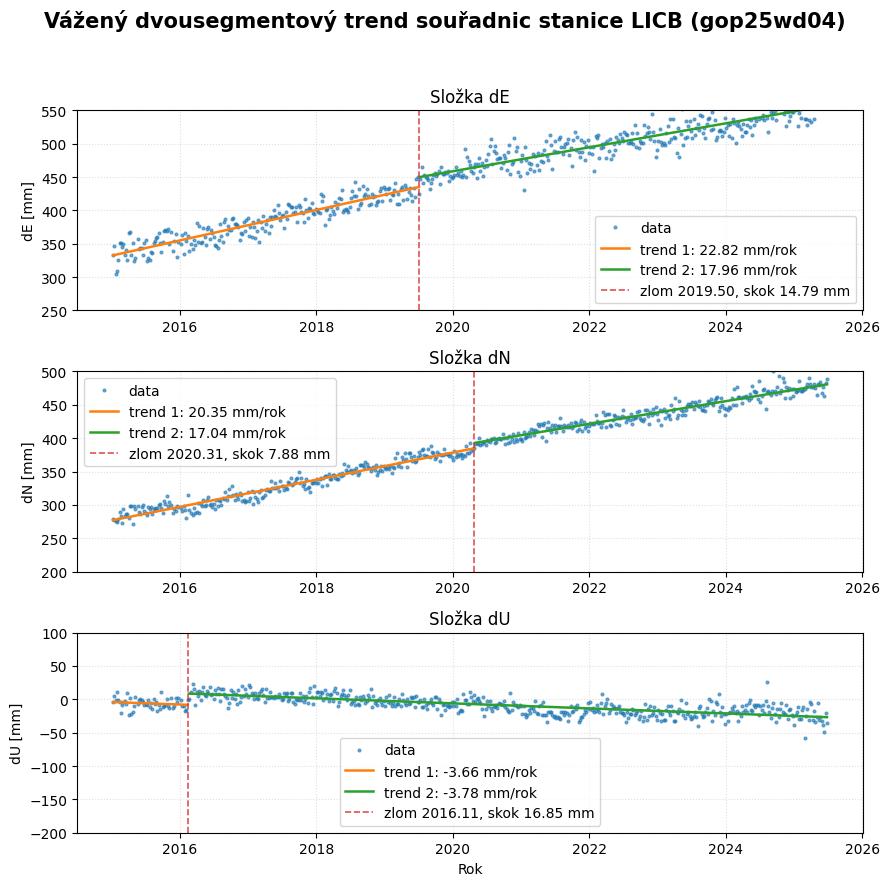

Saved PDF -> C:\Users\michal\Desktop\MasterThesis-DorisAnalysis\data\stcd\gop25wd04\images\licb\gop25wd04_stcd_licb_trend_weighted_2seg.pdf


In [20]:
# --- Plot: weighted 2-segment linear trend ---

components = components

fig, axes = plt.subplots(len(components), 1, figsize=(9, 9), sharex=True, sharey=False)

if len(components) == 1:
    axes = [axes]

x_vals = df_filt["year"].values

component_titles = {
    "dE": "Složka dE",
    "dN": "Složka dN",
    "dU": "Složka dU",
}

trend_colors = ["tab:orange", "tab:green", "tab:purple", "tab:brown"]

for ax, comp in zip(axes, components):
    y_vals = pd.to_numeric(df_filt[comp], errors="coerce").to_numpy()

    ax.plot(
        x_vals, y_vals,
        ".",
        ms=4,
        alpha=0.6,
        color="tab:blue",
        label="data"
    )

    trend = trend2_results.get(comp)

    if trend is not None:
        for i, seg in enumerate(trend.segments):
            x_fit = np.linspace(seg.x_min, seg.x_max, 200)
            y_fit = seg.intercept + seg.slope * x_fit

            ax.plot(
                x_fit, y_fit,
                "-",
                lw=1.8,
                color=trend_colors[i % len(trend_colors)],
                label=f"trend {i+1}: {seg.slope:.2f} mm/rok"
            )

        for bp in trend.breakpoints:
            jump = trend2_df.loc[comp, "jump"]

            ax.axvline(
                bp,
                linestyle="--",
                linewidth=1.2,
                color="tab:red",
                alpha=0.8,
                label=f"zlom {bp:.2f}, skok {jump:.2f} mm"
            )

    ax.set_title(component_titles.get(comp, comp), fontweight="normal")
    ax.set_ylabel(f"{comp} [mm]")
    ax.tick_params(axis="x", labelbottom=True)
    ax.grid(True, linestyle=":", alpha=0.4)
    ax.legend(loc="best")

axes[-1].set_xlabel("Rok")

fig.suptitle(
    f"Vážený dvousegmentový trend souřadnic stanice {STATION.upper()} ({SOLUTION})",
    fontsize=15,
    fontweight="bold"
)

uniform_y_scale_policy(
    axes=axes,
    df=df_filt,
    components=components,
    tick_step=None,
    target_ticks=6,
    tightness="tight",
    min_ticks=3,
    robust=True,
    q_low=1.0,
    q_high=99.0
)

plt.tight_layout(rect=[0, 0, 1, 0.95])

fig.savefig(CONFIG["fit_plot"], bbox_inches="tight")

plt.show()

print("Saved PDF ->", CONFIG["fit_plot"].resolve())

In [21]:
# Weighted 2-segment detrending and CSV export
df_detr_2seg = build_detrended_dataframe(trend2_results)
df_detr_2seg.to_csv(CONFIG["csv"], index=False, float_format="%.6f")
print("Saved CSV ->", CONFIG["csv"].resolve())
display(df_detr_2seg[["year"] + [f"res_{c}" for c in components]].head())


Saved CSV -> C:\Users\michal\Desktop\MasterThesis-DorisAnalysis\data\stcd\gop25wd04\exports\licb\gop25wd04_stcd_licb_detr_weighted_2seg.csv


,year,res_dE,res_dN,res_dU
0,2015.017808,0.498885,1.904198,0.783761
1,2015.036986,13.361186,-0.786098,9.353971
2,2015.056164,-28.176512,-2.676395,2.624181
3,2015.075342,-25.314210,-3.266691,14.694391
4,2015.094521,-9.251908,-0.456987,3.064601


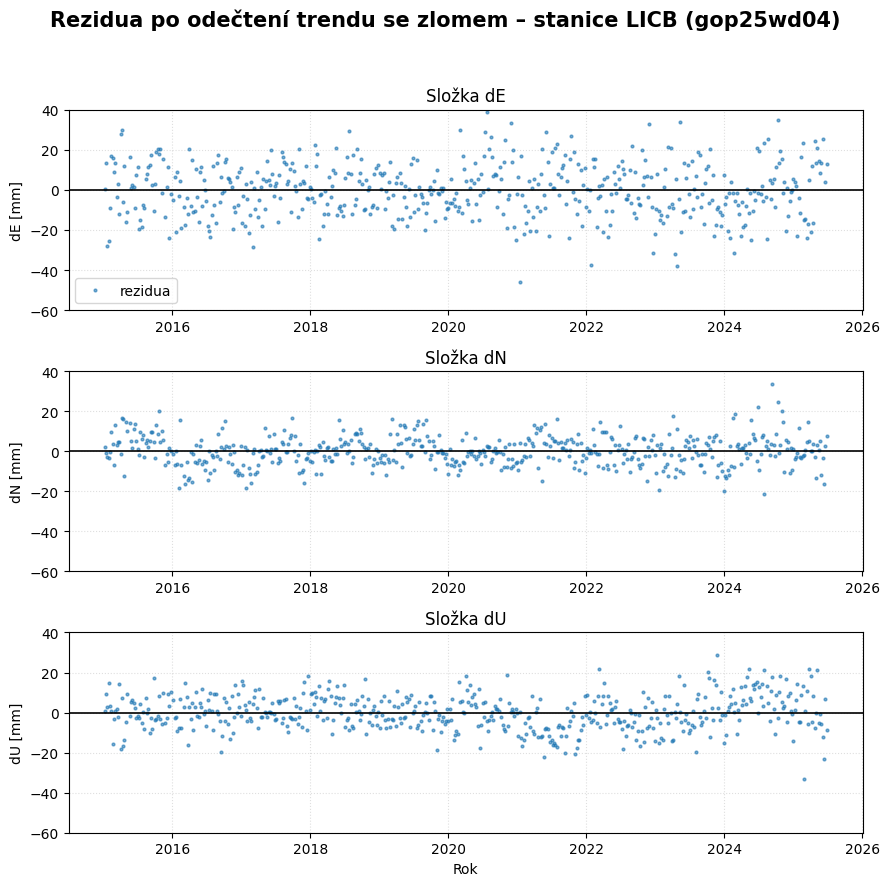

Saved PDF -> C:\Users\michal\Desktop\MasterThesis-DorisAnalysis\data\stcd\gop25wd04\images\licb\gop25wd04_stcd_licb_residuals_weighted_2seg.pdf


In [22]:
# --- Plot: residuals (weighted 2-segment) ---

components = components

fig, axes = plt.subplots(len(components), 1, figsize=(9, 9), sharex=True, sharey=False)

if len(components) == 1:
    axes = [axes]

x_vals = df_detr_2seg["year"].values

component_titles = {
    "dE": "Složka dE",
    "dN": "Složka dN",
    "dU": "Složka dU",
}

for i, (ax, comp) in enumerate(zip(axes, components)):
    y_res = pd.to_numeric(df_detr_2seg[f"res_{comp}"], errors="coerce").to_numpy()

    # Residuals
    ax.plot(
        x_vals, y_res,
        ".",
        ms=4,
        alpha=0.6,
        color="tab:blue",
        label="rezidua" if i == 0 else None
    )

    # Zero line
    ax.axhline(
        0,
        color="black",
        lw=1.2
    )

    # Styling
    ax.set_title(component_titles.get(comp, comp), fontweight="normal")
    ax.set_ylabel(f"{comp} [mm]")
    ax.tick_params(axis="x", labelbottom=True)
    ax.grid(True, linestyle=":", alpha=0.4)

    if i == 0:
        ax.legend(loc="best")

axes[-1].set_xlabel("Rok")

fig.suptitle(
    f"Rezidua po odečtení trendu se zlomem – stanice {STATION.upper()} ({SOLUTION})",
    fontsize=15,
    fontweight="bold"
)

uniform_y_scale_policy(
    axes=axes,
    df=df_detr_2seg,
    components=[f"res_{c}" for c in components],
    tick_step=None,
    target_ticks=6,
    tightness="tight",
    min_ticks=3,
    robust=True,
    q_low=1.0,
    q_high=99.0
)

plt.tight_layout(rect=[0, 0, 1, 0.95])

fig.savefig(CONFIG["residual_plot"], bbox_inches="tight")

plt.show()

print("Saved PDF ->", CONFIG["residual_plot"].resolve())

## Weighted Multi-Segment Trend

This block follows the multi-segment workflow from `Trend_detection.ipynb`, but delegates fitting to `fit_piecewise_trend(...)` from the station trend module and exports raw, fitted, and detrended PDF outputs.

In [23]:
# --- Weighted multi-segment linear trend ---

VARIANT = "weighted_multiseg"
CONFIG = TREND_EXPORTS[VARIANT]

MIN_POINTS_MULTI = 10
MIN_YEARS_MULTI = 1.0
MAX_SEGMENTS_MULTI = 8

x_all = pd.to_numeric(df_filt["year"], errors="coerce").to_numpy()

trend_multi_results = {}

for comp in components:
    y_all = pd.to_numeric(df_filt[comp], errors="coerce").to_numpy()

    try:
        trend_multi_results[comp] = fit_piecewise_trend(
            x_all,
            y_all,
            sigma=component_sigma(comp),
            max_segments=MAX_SEGMENTS_MULTI,
            force_max_segments=False,
            min_points=MIN_POINTS_MULTI,
            min_years=MIN_YEARS_MULTI,
            bic_metric="auto",
        )
    except ValueError:
        trend_multi_results[comp] = None

trend_multi_df = pd.DataFrame(
    trend_summary_rows(trend_multi_results, VARIANT)
).set_index("axis", drop=False)

# Compute jumps at all breakpoints:
# jump = value after breakpoint - value before breakpoint
for comp in components:
    trend = trend_multi_results.get(comp)

    if trend is None or len(trend.breakpoints) == 0:
        trend_multi_df.loc[comp, "jumps"] = ""
        continue

    jumps = []

    for i, bp in enumerate(trend.breakpoints):
        left_segment = trend.segments[i]
        right_segment = trend.segments[i + 1]

        y_before = left_segment.intercept + left_segment.slope * bp
        y_after = right_segment.intercept + right_segment.slope * bp

        jumps.append(y_after - y_before)

    trend_multi_df.loc[comp, "jumps"] = ", ".join(f"{j:.3f}" for j in jumps)

display(
    trend_multi_df[
        [
            "n_segments",
            "breakpoints",
            "slopes",
            "jumps",
            "r2",
            "wrss",
            "bic",
            "weighted",
        ]
    ].round(3)
)

,n_segments,breakpoints,slopes,jumps,r2,wrss,bic,weighted
axis,,,,,,,,
dE,3,"2019.503, 2023.834","22.823, 17.951, 31.733","15.204, -12.922",0.961,1913.237,734.254,True
dN,4,"2017.240, 2019.234, 2020.307","14.471, 19.837, 7.591, 17.037","7.788, 8.611, 13.231",0.986,2938.335,986.118,True
dU,4,"2016.111, 2020.996, 2024.313","-3.661, -4.246, -0.239, -19.797","18.859, -8.538, 11.973",0.614,1909.446,752.068,True


In [24]:
# --- Weighted multi-segment LaTeX table (clean version) ---

latex_multiseg = trend_multi_df[
    ["axis", "n_segments", "breakpoints", "slopes", "jumps", "r2", "wrss", "bic"]
].copy()

latex_multiseg = latex_multiseg.rename(columns={
    "axis": "Složka",
    "n_segments": "Segmenty",
    "breakpoints": "Zlomy [rok]",
    "slopes": "Směrnice [mm/rok]",
    "jumps": "Skoky [mm]",
    "r2": "$R^2$",
    "wrss": "WRSS [-]",
    "bic": "BIC [-]",
})

# round numeric columns only
for col in ["$R^2$", "WRSS [-]", "BIC [-]"]:
    latex_multiseg[col] = pd.to_numeric(latex_multiseg[col], errors="coerce").round(3)

latex_str = latex_multiseg.to_latex(
    index=False,
    caption=(
        f"Vážený vícesegmentový lineární trend souřadnic "
        f"stanice {STATION.upper()} (řešení {SOLUTION})"
    ),
    label=f"tab:{IMAGE_NAME}_weighted_multiseg",
    escape=False,
)

CONFIG["tex"].write_text(latex_str, encoding="utf-8")

print(latex_str)
print("Saved TeX ->", CONFIG["tex"].resolve())

\begin{table}
\caption{Vážený vícesegmentový lineární trend souřadnic stanice LICB (řešení gop25wd04)}
\label{tab:gop25wd04_stcd_licb_weighted_multiseg}
\begin{tabular}{lrlllrrr}
\toprule
Složka & Segmenty & Zlomy [rok] & Směrnice [mm/rok] & Skoky [mm] & $R^2$ & WRSS [-] & BIC [-] \\
\midrule
dE & 3 & 2019.503, 2023.834 & 22.823, 17.951, 31.733 & 15.204, -12.922 & 0.961000 & 1913.237000 & 734.254000 \\
dN & 4 & 2017.240, 2019.234, 2020.307 & 14.471, 19.837, 7.591, 17.037 & 7.788, 8.611, 13.231 & 0.986000 & 2938.335000 & 986.118000 \\
dU & 4 & 2016.111, 2020.996, 2024.313 & -3.661, -4.246, -0.239, -19.797 & 18.859, -8.538, 11.973 & 0.614000 & 1909.446000 & 752.068000 \\
\bottomrule
\end{tabular}
\end{table}

Saved TeX -> C:\Users\michal\Desktop\MasterThesis-DorisAnalysis\data\stcd\gop25wd04\exports\licb\gop25wd04_stcd_licb_trend_table_weighted_multiseg.tex


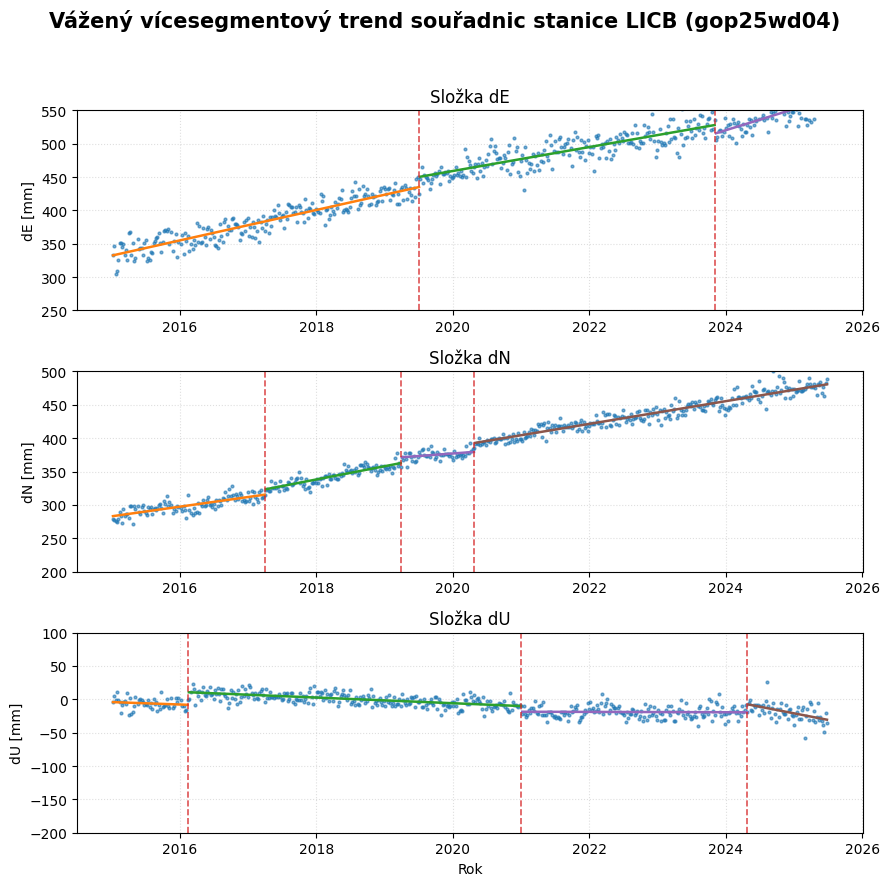

Saved PDF -> C:\Users\michal\Desktop\MasterThesis-DorisAnalysis\data\stcd\gop25wd04\images\licb\gop25wd04_stcd_licb_trend_weighted_multiseg.pdf


In [25]:
# --- Plot: weighted multi-segment linear trend ---

components = components

fig, axes = plt.subplots(len(components), 1, figsize=(9, 9), sharex=True, sharey=False)

if len(components) == 1:
    axes = [axes]

x_vals = df_filt["year"].values

component_titles = {
    "dE": "Složka dE",
    "dN": "Složka dN",
    "dU": "Složka dU",
}

trend_colors = ["tab:orange", "tab:green", "tab:purple", "tab:brown", "tab:pink", "tab:gray"]

for ax, comp in zip(axes, components):
    y_vals = pd.to_numeric(df_filt[comp], errors="coerce").to_numpy()

    # Data
    ax.plot(
        x_vals, y_vals,
        ".",
        ms=4,
        alpha=0.6,
        color="tab:blue"
    )

    # Multi-segment trend
    trend = trend_multi_results.get(comp)

    if trend is not None:
        for i, seg in enumerate(trend.segments):
            x_fit = np.linspace(seg.x_min, seg.x_max, 200)
            y_fit = seg.intercept + seg.slope * x_fit

            ax.plot(
                x_fit, y_fit,
                "-",
                lw=1.8,
                color=trend_colors[i % len(trend_colors)]
            )

        for bp in trend.breakpoints:
            ax.axvline(
                bp,
                linestyle="--",
                linewidth=1.2,
                color="tab:red",
                alpha=0.8
            )

    # Styling
    ax.set_title(component_titles.get(comp, comp), fontweight="normal")
    ax.set_ylabel(f"{comp} [mm]")
    ax.tick_params(axis="x", labelbottom=True)
    ax.grid(True, linestyle=":", alpha=0.4)

axes[-1].set_xlabel("Rok")

fig.suptitle(
    f"Vážený vícesegmentový trend souřadnic stanice {STATION.upper()} ({SOLUTION})",
    fontsize=15,
    fontweight="bold"
)

uniform_y_scale_policy(
    axes=axes,
    df=df_filt,
    components=components,
    tick_step=None,
    target_ticks=6,
    tightness="tight",
    min_ticks=3,
    robust=True,
    q_low=1.0,
    q_high=99.0
)

plt.tight_layout(rect=[0, 0, 1, 0.95])

fig.savefig(CONFIG["fit_plot"], bbox_inches="tight")

plt.show()

print("Saved PDF ->", CONFIG["fit_plot"].resolve())

In [26]:
# Weighted multi-segment detrending and CSV export
df_detr_multiseg = build_detrended_dataframe(trend_multi_results)

df_detr_multiseg.to_csv(CONFIG["csv"], index=False, float_format="%.6f")

print("Saved CSV ->", CONFIG["csv"].resolve())

display(
    df_detr_multiseg[
        ["year"] + [f"res_{c}" for c in components]
    ].head()
)

Saved CSV -> C:\Users\michal\Desktop\MasterThesis-DorisAnalysis\data\stcd\gop25wd04\exports\licb\gop25wd04_stcd_licb_detr_weighted_multiseg.csv


,year,res_dE,res_dN,res_dU
0,2015.017808,0.498885,-4.131528,0.783761
1,2015.036986,13.361186,-6.709047,9.353971
2,2015.056164,-28.176512,-8.486566,2.624181
3,2015.075342,-25.314210,-8.964085,14.694391
4,2015.094521,-9.251908,-6.041604,3.064601


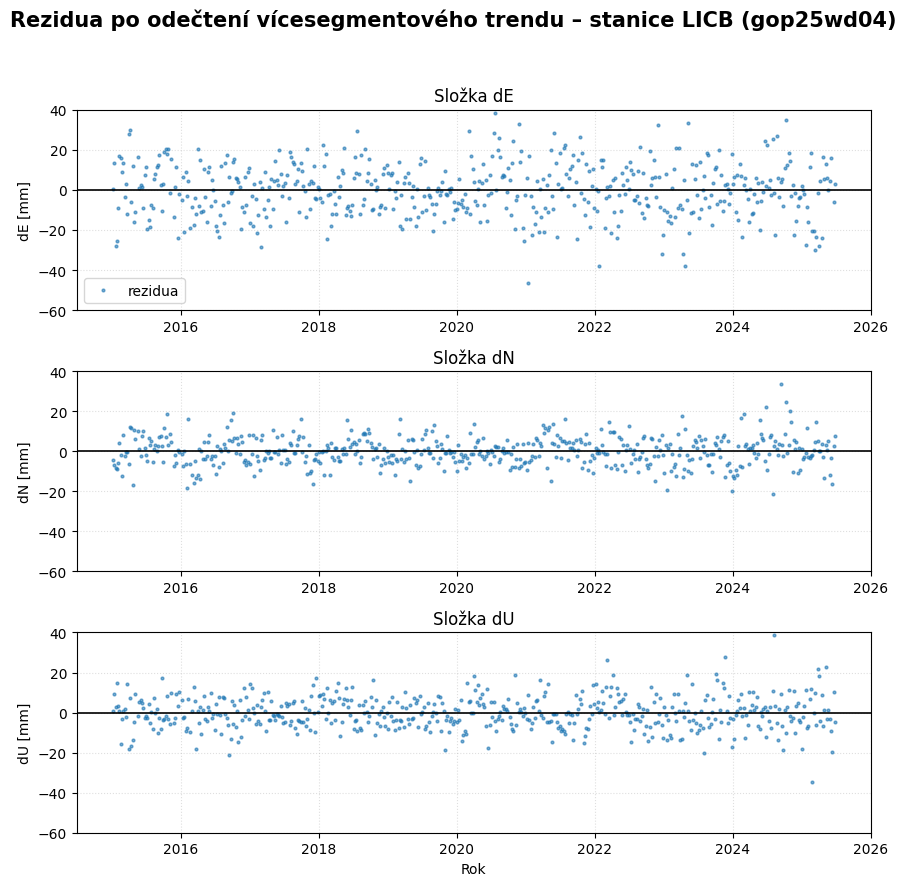

Saved PDF -> C:\Users\michal\Desktop\MasterThesis-DorisAnalysis\data\stcd\gop25wd04\images\licb\gop25wd04_stcd_licb_residuals_weighted_multiseg.pdf


In [27]:
# --- Plot: residuals (weighted multi-segment) ---

components = components

fig, axes = plt.subplots(len(components), 1, figsize=(9, 9), sharex=True, sharey=False)

if len(components) == 1:
    axes = [axes]

x_vals = df_detr_multiseg["year"].values

component_titles = {
    "dE": "Složka dE",
    "dN": "Složka dN",
    "dU": "Složka dU",
}

for i, (ax, comp) in enumerate(zip(axes, components)):
    y_res = pd.to_numeric(df_detr_multiseg[f"res_{comp}"], errors="coerce").to_numpy()

    # Residuals
    ax.plot(
        x_vals, y_res,
        ".",
        ms=4,
        alpha=0.6,
        color="tab:blue",
        label="rezidua" if i == 0 else None
    )

    # Zero line
    ax.axhline(
        0,
        color="black",
        lw=1.2
    )

    # Styling
    ax.set_title(component_titles.get(comp, comp), fontweight="normal")
    ax.set_ylabel(f"{comp} [mm]")
    ax.tick_params(axis="x", labelbottom=True)
    ax.grid(True, linestyle=":", alpha=0.4)

    if i == 0:
        ax.legend(loc="best")

axes[-1].set_xlabel("Rok")

fig.suptitle(
    f"Rezidua po odečtení vícesegmentového trendu – stanice {STATION.upper()} ({SOLUTION})",
    fontsize=15,
    fontweight="bold"
)

uniform_y_scale_policy(
    axes=axes,
    df=df_detr_multiseg,
    components=[f"res_{c}" for c in components],
    tick_step=None,
    target_ticks=6,
    tightness="tight",
    min_ticks=3,
    robust=True,
    q_low=1.0,
    q_high=99.0
)

plt.tight_layout(rect=[0, 0, 1, 0.95])

fig.savefig(CONFIG["residual_plot"], bbox_inches="tight")

plt.show()

print("Saved PDF ->", CONFIG["residual_plot"].resolve())